__Docker от selfedu__

__Что такое Docker__

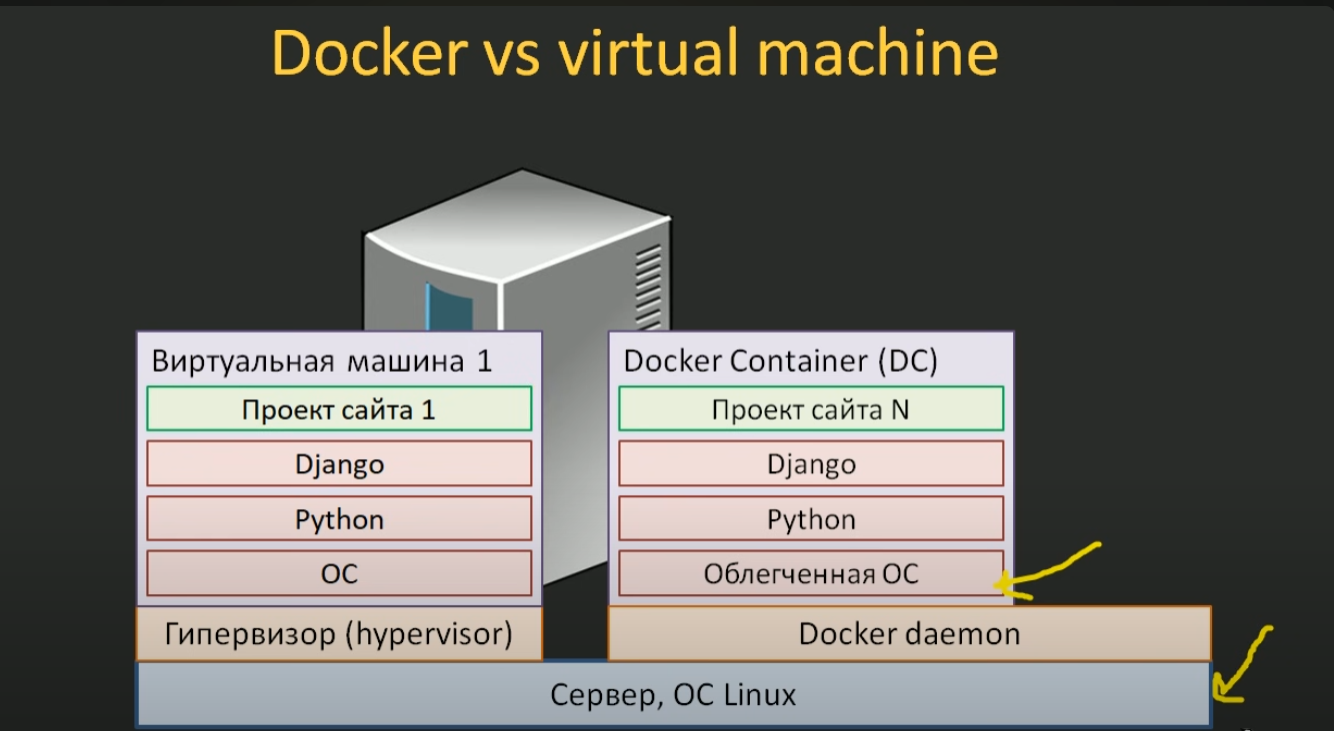

image(образ) - файл, в котором собрана вся необходимая информация для автоматического создания и запуска оболочки с набором программных компонентов

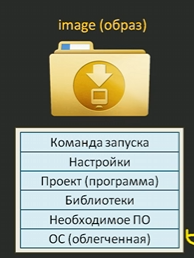

Имея образ с помощью команды docker run < имя образа > можно запустить оболочку проекта, которая называется контейнером

Контейнер - изолированная среда со своей ОС, набором необходимых утилит, библиотек и разработанным проектом

Все это работает в виде отдельного процесса, который работает на сервере

На основе одного образа можно запускать несколько контейнеров

Ядро системы - Docker Engine

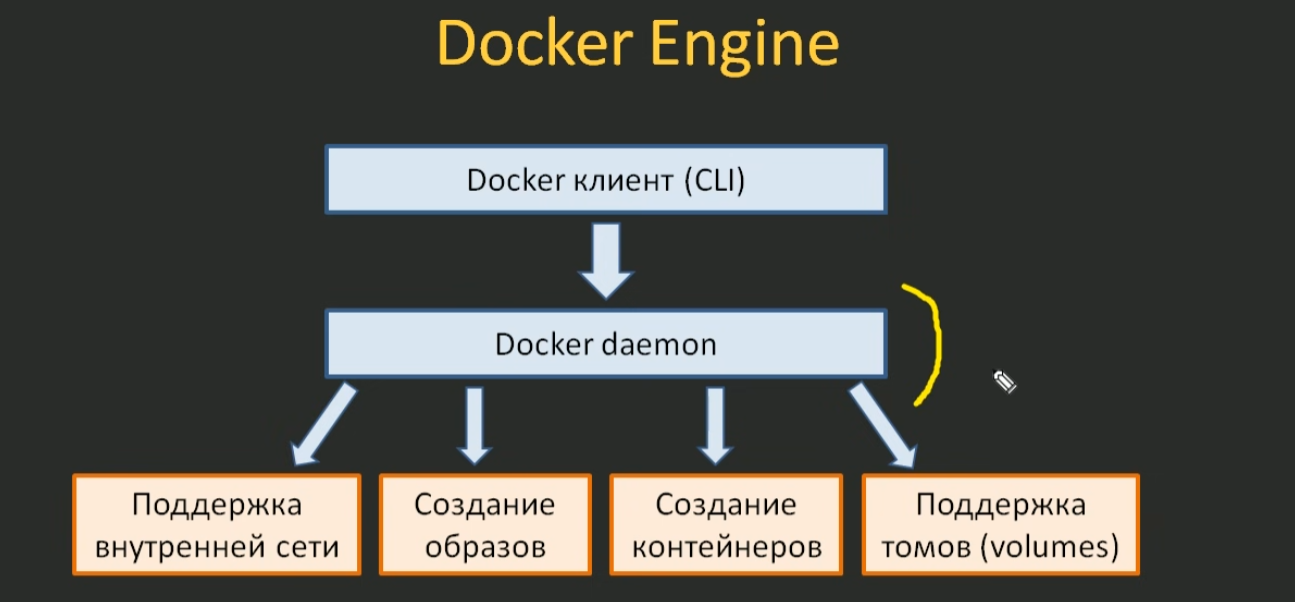

Docker Daemon - постоянно запущенный фоновый процесс.

__Dockerfile | Создание новых образов__

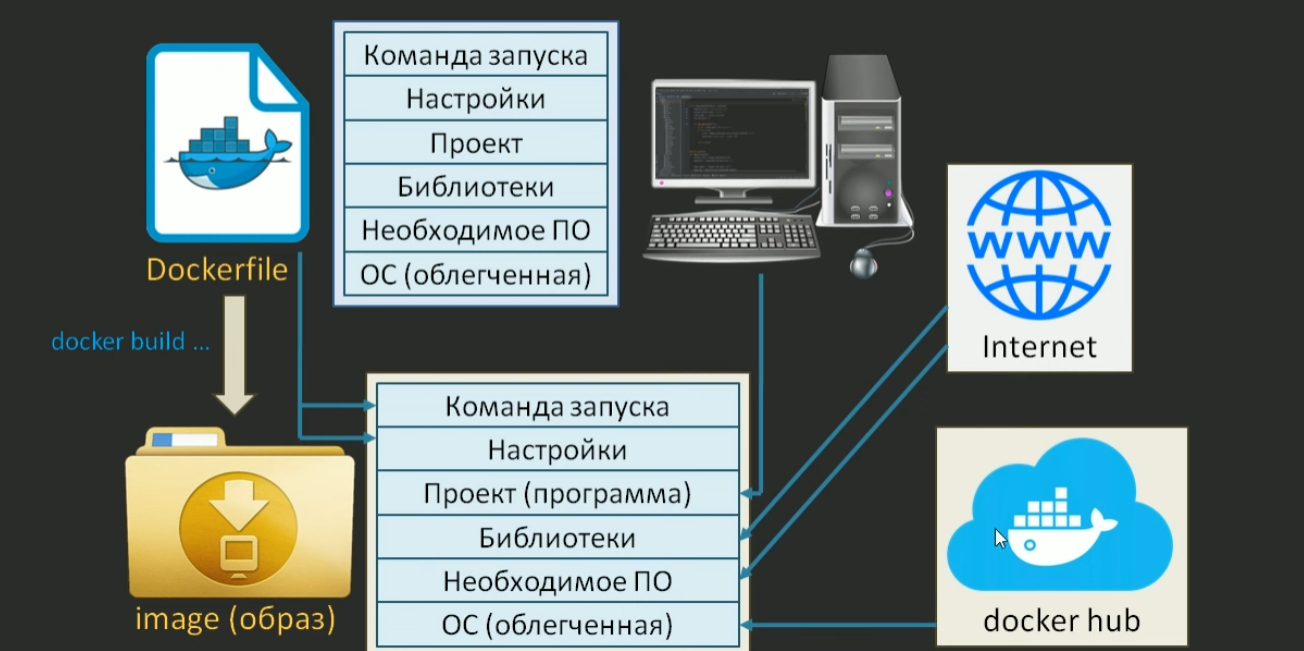

Для работы с VSCode нужно установить расширения:

- Docker 
- Dev Containers

Вот допустим есть проект:

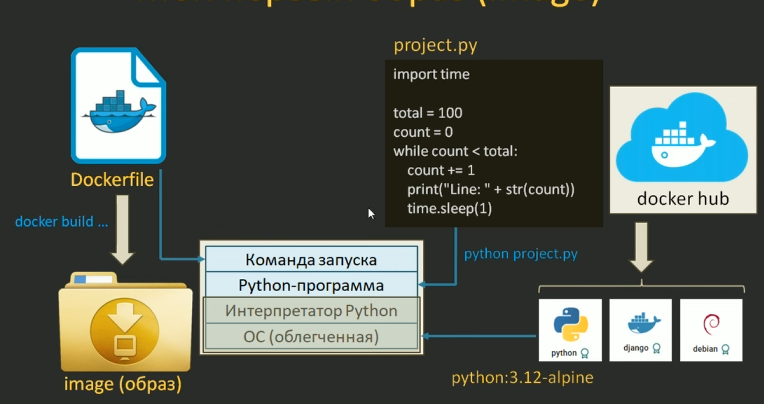

Чтоб реализовать все нужно прописать Dockerfile, первая команда - первый слой в образе (ОС) -> FROM python:3.12-alpine

Затем мы создадим подкаталог WORKDIR /python-app

Дальше копируем файлы проекта в этот рабочий каталог (. означают текущий каталог)

Последняя строчка команда запуска, которая должна запускаться при создании образа

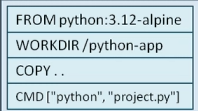

Затем создаем образ с помощью команды:



__Особенности создания__

Если у нас есть сторонние библиотеки, то нужно указывать на их скачку в Dockerfile

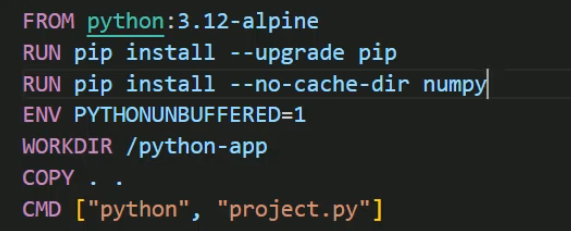

Для удобства конечно используют requiements.txt, где после прописывают прост файл (для начала его скопирпуют в рабочий каталог)

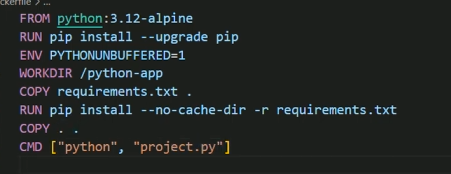

__Работа с портами внутренней сети Docker__

Docker при запуске ядра формирует свою независимую от хоста внутреннню сеть, которую могут использовать контейнеры

Однако для взаимодействия внешней сети сетью докера можно открывать отдельные порты через которые возможен обменя информационными пакетами между хостом и контейнером

1) Создадим образ nginx

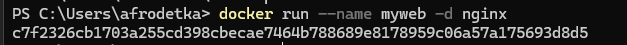

чтобы посмотреть информацию о контейнере:

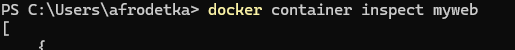

В NetworkSetting увидим ip-adress:



До веб-сервера запросы от хоста не доходят, потому что внутрення и внешняя сети ни связаны

Чтобы исправить это - необходимо открыть порт

Удалим контейнер:

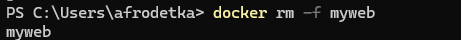

флаг -f позволяет автоматически остановить контейнер

2) Пересоздадим образ, разрешив работу с портами (флаг -p)

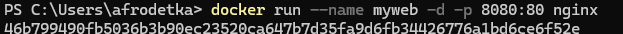

Также можно явно указать айпи-адрес:

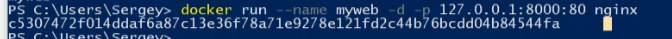

так можно открыть терминал контейнера:



Выход из контейнера -> exit

Увидим html:

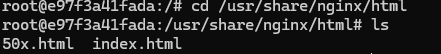

__Работа с томами__

Volume — это специальное место на хост-машине (вашем ноутбуке или сервере), которое подключили внутрь контейнера для постоянного хранения данных.

Контейнеры при удалении теряют данные -> чтоб хранить их мы можем использовать volumes (тома)

Зачем это нужно? 3 главные причины:

1) Сохранять данные между перезапусками контейнера.

Пример: База данных (PostgreSQL, MySQL). Без тома все ваши данные удалятся при остановке контейнера.

2) Обмениваться данными между контейнерами.

Пример: Один контейнер генерирует отчеты, а другой контейнер (Nginx) раздает их пользователям. Они оба используют один и тот же том.

3) Разрабатывать приложения без постоянной пересборки образа.

Пример: Вы можете "подмонтировать" папку с кодом с вашего ноутбука прямо в контейнер. Вы редактируете код в любимой IDE на ноутбуке, а изменения мгновенно становятся видны внутри контейнера.

Существует три вида монтирования томов:

1) Named Value для базы данных

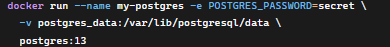

2) Bind Mount для разработки

В докерфайле мы не копируем код:

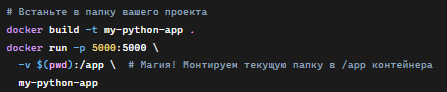

Вы пишете код на Python на своем ноутбуке, а запускаете его внутри контейнера.

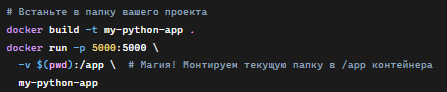

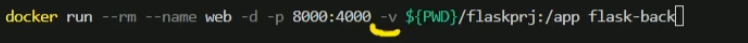

флаг -v как раз выполняет монтирование томов